# 2D Annotation → 3D Joint Angles via Inverse Kinematics

Pipeline:
1. Parse CVAT skeleton annotations (2D pixel keypoints per frame)
2. Load URDF skeleton with forward kinematics
3. Solve IK: find joint angles that project to match the 2D annotations
4. Export joint angle trajectories for BC training

In [1]:
import numpy as np
import xml.etree.ElementTree as ET
from scipy.optimize import minimize
from scipy.spatial.transform import Rotation as R
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import os, sys

# Add skeleton code to path
sys.path.insert(0, '/home/caee/Desktop/Excavator_BC_RL')
from urdf_skeleton_custom import CustomURDFSkeleton

print('Imports loaded')

Imports loaded


## 1. Parse CVAT Annotations

Read the CVAT XML and extract per-frame 2D keypoints + occlusion flags.

In [16]:
# --- Configuration ---
annotation_path = '/home/caee/Desktop/RL_project/0_dig/1/annotations.xml'
frames_dir = '/home/caee/Desktop/RL_project/0_dig/1'

# Keypoint order must match skeleton definition below
KEYPOINT_ORDER = [
    'frame_front_mid',
    'frame_rear_mid',
    'turret_center',
    'arm_base',
    'boom_tip',
    'stick_tip',
    'bucket_floor',
    'bucket_tip',
]

# --- Parse CVAT XML ---
tree = ET.parse(annotation_path)
root = tree.getroot()

# Find total frames from meta
meta = root.find('meta/task')
if meta is None:
    meta = root.find('meta/job')
n_frames = int(meta.find('size').text)
print(f'Video: {n_frames} frames')

# Parse all skeleton tracks
n_kp = len(KEYPOINT_ORDER)
keypoints_2d = np.zeros((n_frames, n_kp, 2))  # (T, 8, 2)
visibility = np.ones((n_frames, n_kp))          # (T, 8) - 1=visible, 0=occluded

for track in root.findall('track'):
    if track.get('label') != 'exc':
        continue
    for skeleton in track.findall('skeleton'):
        frame_idx = int(skeleton.get('frame'))
        for points in skeleton.findall('points'):
            label = points.get('label')
            if label not in KEYPOINT_ORDER:
                continue
            kp_idx = KEYPOINT_ORDER.index(label)
            xy = points.get('points').split(',')
            keypoints_2d[frame_idx, kp_idx, 0] = float(xy[0])
            keypoints_2d[frame_idx, kp_idx, 1] = float(xy[1])
            # Mark occluded keypoints
            if points.get('occluded') == '1' or points.get('outside') == '1':
                visibility[frame_idx, kp_idx] = 0.0

print(f'Parsed: keypoints_2d {keypoints_2d.shape}, visibility {visibility.shape}')
print(f'Visible keypoints per frame: min={visibility.sum(axis=1).min():.0f}, max={visibility.sum(axis=1).max():.0f}')
print()

# Show sample
print('Frame 0 keypoints:')
for i, name in enumerate(KEYPOINT_ORDER):
    vis = 'visible' if visibility[0, i] > 0.5 else 'OCCLUDED'
    print(f'  {name:20s}: ({keypoints_2d[0,i,0]:.1f}, {keypoints_2d[0,i,1]:.1f})  [{vis}]')

Video: 112 frames
Parsed: keypoints_2d (112, 8, 2), visibility (112, 8)
Visible keypoints per frame: min=8, max=8

Frame 0 keypoints:
  frame_front_mid     : (329.9, 225.3)  [visible]
  frame_rear_mid      : (445.6, 228.7)  [visible]
  turret_center       : (390.9, 227.6)  [visible]
  arm_base            : (341.6, 185.8)  [visible]
  boom_tip            : (251.7, 142.8)  [visible]
  stick_tip           : (217.7, 171.1)  [visible]
  bucket_floor        : (194.1, 203.9)  [visible]
  bucket_tip          : (228.4, 216.3)  [visible]


## 2. Visualize Annotations on Frames

Sanity check: make sure keypoints land on the right spots.

Total frames available: 112
Frame files range: 00000.jpg to 00111.jpg


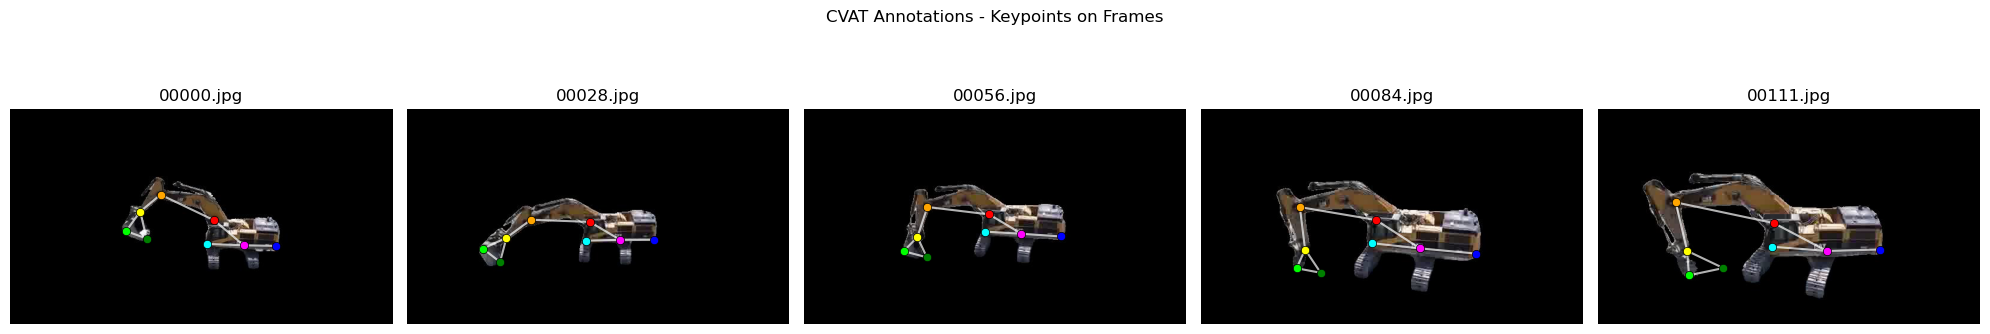

In [17]:
# Get sorted list of actual frame files
frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.jpg')])
print(f"Total frames available: {len(frame_files)}")
print(f"Frame files range: {frame_files[0]} to {frame_files[-1]}")

# Show annotations on a few sample frames
sample_indices = [0, len(frame_files) // 4, len(frame_files) // 2, 3 * len(frame_files) // 4, min(len(frame_files) - 1, n_frames - 1)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(20, 4))

colors = ['cyan', 'blue', 'magenta', 'red', 'orange', 'yellow', 'lime', 'green']

# Skeleton connections for drawing
skeleton_edges = [
    ('frame_front_mid', 'turret_center'),
    ('turret_center', 'frame_rear_mid'),
    ('turret_center', 'arm_base'),
    ('arm_base', 'boom_tip'),
    ('boom_tip', 'stick_tip'),
    ('stick_tip', 'bucket_floor'),
    ('bucket_floor', 'bucket_tip'),
    ('bucket_tip', 'stick_tip'),
]

for ax, idx in zip(axes, sample_indices):
    # Use actual filename from sorted list
    img_path = os.path.join(frames_dir, frame_files[idx])
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        ax.imshow(img)
    else:
        print(f"✗ Not found: {frame_files[idx]}")
    
    fi = idx  # Frame index in annotation data
    
    # Draw skeleton edges
    for p1_name, p2_name in skeleton_edges:
        i1 = KEYPOINT_ORDER.index(p1_name)
        i2 = KEYPOINT_ORDER.index(p2_name)
        if visibility[fi, i1] > 0.5 and visibility[fi, i2] > 0.5:
            ax.plot([keypoints_2d[fi,i1,0], keypoints_2d[fi,i2,0]],
                    [keypoints_2d[fi,i1,1], keypoints_2d[fi,i2,1]],
                    'w-', linewidth=1.5, alpha=0.7)
    
    # Draw keypoints
    for i, name in enumerate(KEYPOINT_ORDER):
        if visibility[fi, i] > 0.5:
            ax.plot(keypoints_2d[fi,i,0], keypoints_2d[fi,i,1], 'o',
                    color=colors[i], markersize=6, markeredgecolor='black', markeredgewidth=0.5)
    
    ax.set_title(f'{frame_files[idx]}')
    ax.axis('off')

plt.suptitle('CVAT Annotations - Keypoints on Frames')
plt.tight_layout()
plt.show()

## 3. Set Up URDF Skeleton

Load the URDF and define the 4 movable joints + 8 keypoints.

**Movable joints** (what we solve for):
- `full_arm_rotation` → at turret_center
- `lower_arm` → at arm_base
- `upperToLow` → at boom_tip
- `scoop1` → at stick_tip

**Body keypoints** (frame_front_mid, frame_rear_mid, turret_center) are static — they
help constrain the camera parameters.

In [18]:
# --- Load URDF skeleton ---
urdf_path = '/home/caee/Desktop/Excavator_BC_RL/excavatorURDF/robot_fixed_alternate.urdf'
skeleton = CustomURDFSkeleton(urdf_path)

# 4 movable arm joints (in kinematic chain order)
arm_joints = ['full_arm_rotation', 'lower_arm', 'upperToLow', 'scoop1']

# --- CORRECTED: All body keypoints are on the TURRET/CABIN (not base frame) ---
# Since frame_front_mid and frame_rear_mid were annotated on the cabin,
# they should rotate with the turret. All 3 body keypoints form a rigid triangle.

# Define keypoints - all body points on turret link
keypoints_def = [
    # Body keypoints on TURRET - these rotate together as a rigid triangle
    # Offsets are in the turret link's local frame
    ('frame_front_mid', 'compact_excavator_turret_cabin_roller', 
     np.array([-0.250000, -0.800000, -0.050000])),  # front of cabin
    ('frame_rear_mid', 'compact_excavator_turret_cabin_roller',
     np.array([-0.250000, 0.800000, -0.050000])),   # rear of cabin
    ('turret_center', 'compact_excavator_turret_cabin_roller',
     np.array([-0.250000, -0.000000, -0.050000])),  # center of turret

    # Arm keypoints - local offsets (FK properly transforms these)
    ('arm_base', 'part01_pin_1', np.array([-0.008162, 0.101433, -0.319600])),
    ('boom_tip', 'part02_cmpl', np.array([-0.859550, 2.365801, -0.103979])),
    ('stick_tip', 'part03', np.array([0.103279, -1.463410, -0.081342])),
    ('bucket_floor', 'part04', np.array([0.453952, 0.489494, -0.005257])),
    ('bucket_tip', 'part04', np.array([0.102095, 1.017336, 0.109654])),
]

skeleton.define_skeleton(arm_joints, keypoints_def)

# Verify FK at rest pose
rest_3d = skeleton.forward_kinematics(np.zeros(4))
print('FK at rest pose (all joints = 0):')
for i, name in enumerate(KEYPOINT_ORDER):
    print(f'  {name:20s}: [{rest_3d[i,0]:.3f}, {rest_3d[i,1]:.3f}, {rest_3d[i,2]:.3f}]')

print('\nBody keypoints (should form rigid triangle on turret):')
print(f'  Distance frame_front to turret_center: {np.linalg.norm(rest_3d[0] - rest_3d[2]):.3f}m')
print(f'  Distance frame_rear to turret_center: {np.linalg.norm(rest_3d[1] - rest_3d[2]):.3f}m')
print(f'  Distance frame_front to frame_rear: {np.linalg.norm(rest_3d[0] - rest_3d[1]):.3f}m')

Loaded URDF: /home/caee/Desktop/Excavator_BC_RL/excavatorURDF/robot_fixed_alternate.urdf
Available joints: ['left_sprocket_wheel', 'right_sprocket_wheel', 'left_idle_passive_wheel', 'right_idle_passive_wheel', 'roll_wheel_1', 'roll_wheel_2', 'roll_wheel_3', 'roll_wheel_4', 'roll_wheel_5', 'roll_wheel_6', 'idler1_wheel', 'idler2_wheel', 'tankSpin_wheel', 'fixed_base', 'scoop1', 'upperToLow', 'lower_arm', 'full_arm_rotation']

✓ Skeleton defined:
  Arm joints (4): ['full_arm_rotation', 'lower_arm', 'upperToLow', 'scoop1']
  Keypoints (8):
    0. frame_front_mid -> link 'compact_excavator_turret_cabin_roller' + offset [-0.25 -0.8  -0.05]
    1. frame_rear_mid -> link 'compact_excavator_turret_cabin_roller' + offset [-0.25  0.8  -0.05]
    2. turret_center -> link 'compact_excavator_turret_cabin_roller' + offset [-0.25 -0.   -0.05]
    3. arm_base -> link 'part01_pin_1' + offset [-0.008162  0.101433 -0.3196  ]
    4. boom_tip -> link 'part02_cmpl' + offset [-0.85955   2.365801 -0.103979]
 

## 4. Side-View IK Solver

The video is a **side view** of the excavator. The arm moves in the YZ plane (3D),
which maps to pixel XY. We solve for joint angles that minimize the reprojection error
between the projected 3D skeleton and the 2D annotations.

In [19]:
class SideViewIK:
    """IK solver that fits ALL keypoints together to get correct base pose.
    
    Single-stage optimization of: base + all joints + camera
    This ensures the base is positioned correctly for the actual arm configuration.
    """

    def __init__(self, skeleton):
        self.skeleton = skeleton
        self.joint_lower, self.joint_upper = skeleton.get_joint_limits()
        self.n_joints = len(skeleton.arm_joints)
        self.n_kp = len(skeleton.keypoints)
        self.prev_angles = None
        self.prev_camera = None
        self.prev_base = None
        self.init_camera = None

        self.body_indices = [
            KEYPOINT_ORDER.index('frame_front_mid'),
            KEYPOINT_ORDER.index('frame_rear_mid'),
            KEYPOINT_ORDER.index('turret_center'),
            KEYPOINT_ORDER.index('arm_base'),
        ]
        
        self.arm_indices = [
            KEYPOINT_ORDER.index('boom_tip'),
            KEYPOINT_ORDER.index('stick_tip'),
            KEYPOINT_ORDER.index('bucket_floor'),
            KEYPOINT_ORDER.index('bucket_tip'),
        ]

        self.turret_idx = 0
        self.arm_joint_indices = [1, 2, 3]

    def forward_kinematics_with_base(self, joint_angles, base_pose):
        """FK with base pose transformation."""
        kp_base_frame = self.skeleton.forward_kinematics(joint_angles)
        base_pos = np.array(base_pose[:3])
        base_rot = R.from_euler('xyz', base_pose[3:6]).as_matrix()
        kp_world = (base_rot @ kp_base_frame.T).T + base_pos
        return kp_world

    def project(self, points_3d, camera_params):
        """Weak perspective projection."""
        rx, ry, rz, tx, ty, tz, scale, cx, cy = camera_params
        R_mat = R.from_euler('xyz', [rx, ry, rz]).as_matrix()
        t = np.array([tx, ty, tz])
        points_cam = (R_mat @ points_3d.T).T + t
        pts_2d = np.zeros((len(points_3d), 2))
        pts_2d[:, 0] = scale * points_cam[:, 0] + cx
        pts_2d[:, 1] = scale * points_cam[:, 1] + cy
        return pts_2d

    def estimate_turret_rotation(self, kp_2d):
        """Estimate initial turret rotation from body triangle."""
        frame_front_2d = kp_2d[self.body_indices[0]]
        frame_rear_2d = kp_2d[self.body_indices[1]]
        dx = frame_front_2d[0] - frame_rear_2d[0]
        return np.pi if dx > 0 else 0.0

    def fit_frame(self, kp_2d, vis, temporal_weight=0.1, camera_weight=0.01, base_weight=0.01):
        """Single-stage optimization: base + all joints + camera."""
        
        turret_rot_est = self.estimate_turret_rotation(kp_2d)
        
        # Initialize all joints
        if self.prev_angles is not None:
            init_angles = self.prev_angles.copy()
            init_angles[self.turret_idx] = turret_rot_est
        else:
            init_angles = (self.joint_lower + self.joint_upper) / 2
            init_angles[self.turret_idx] = turret_rot_est

        # Initialize base
        if self.prev_base is not None:
            init_base = self.prev_base.copy()
        else:
            init_base = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

        # Initialize camera
        if self.prev_camera is not None:
            init_camera = self.prev_camera.copy()
        else:
            visible = kp_2d[vis > 0.5]
            cx = np.mean(visible[:, 0]) if len(visible) > 1 else 320
            cy = np.mean(visible[:, 1]) if len(visible) > 1 else 240
            init_camera = np.array([0.0, -np.pi/2, 0.0, -5.0, 0.0, 1.0, 100.0, cx, cy])
            self.init_camera = init_camera.copy()

        # Optimize: base (6) + all joints (4) + camera (9) = 19 params
        x0 = np.concatenate([init_base, init_angles, init_camera])

        def loss(x):
            base_pose = x[:6]
            angles = x[6:10]
            cam = x[10:]
            
            kp_3d = self.forward_kinematics_with_base(angles, base_pose)
            kp_proj = self.project(kp_3d, cam)
            
            # All keypoints with equal weight (no bias)
            diff = kp_2d - kp_proj
            reproj = np.sum((diff ** 2) * vis[:, np.newaxis])
            
            # Temporal smoothness
            temporal = 0.0
            if self.prev_angles is not None and temporal_weight > 0:
                temporal = temporal_weight * np.sum((angles - self.prev_angles) ** 2)
            
            # Base smoothness
            base_smooth = 0.0
            if self.prev_base is not None and base_weight > 0:
                base_smooth = base_weight * np.sum((base_pose - self.prev_base) ** 2)
            
            # Camera regularization
            cam_reg = 0.0
            if self.init_camera is not None and camera_weight > 0:
                cam_reg = camera_weight * np.sum((cam[:6] - self.init_camera[:6]) ** 2)
            
            return reproj + temporal + base_smooth + cam_reg

        # Bounds
        bounds = [
            # Base (6)
            (-10.0, 10.0), (-10.0, 10.0), (-2.0, 2.0),
            (-np.pi/6, np.pi/6), (-np.pi/6, np.pi/6), (-np.pi, np.pi),
            # All joints (4)
            *[(self.joint_lower[i], self.joint_upper[i]) for i in range(self.n_joints)],
            # Camera (9)
            (-np.pi/2, np.pi/2), (-3*np.pi/4, -np.pi/4), (-np.pi/2, np.pi/2),
            (-30.0, 5.0), (-10.0, 10.0), (-5.0, 10.0),
            (10.0, 1000.0), (0.0, 3000.0), (0.0, 3000.0),
        ]

        result = minimize(loss, x0, method='L-BFGS-B', bounds=bounds, 
                         options={'maxiter': 3000})
        
        base_pose = result.x[:6]
        final_angles = result.x[6:10]
        camera_params = result.x[10:]

        self.prev_angles = final_angles.copy()
        self.prev_camera = camera_params.copy()
        self.prev_base = base_pose.copy()

        # Compute errors
        kp_3d = self.forward_kinematics_with_base(final_angles, base_pose)
        kp_proj = self.project(kp_3d, camera_params)
        
        body_err = np.mean(np.sum((kp_2d[self.body_indices] - kp_proj[self.body_indices]) ** 2, axis=1))
        arm_vis = vis[self.arm_indices]
        n_visible_arm = np.sum(arm_vis > 0.5)
        if n_visible_arm > 0:
            arm_err = np.mean(np.sum((kp_2d[self.arm_indices] - kp_proj[self.arm_indices]) ** 2, axis=1)[arm_vis > 0.5])
        else:
            arm_err = 0.0
        vis_err = np.mean(np.sum((kp_2d - kp_proj) ** 2, axis=1)[vis > 0.5])

        return {
            'joint_angles': final_angles,
            'camera_params': camera_params,
            'base_pose': base_pose,
            'error': vis_err,
            'body_error': body_err,
            'arm_error': arm_err,
            'projected_2d': kp_proj,
            'keypoints_3d': kp_3d,
            'success': result.success,
            'n_visible_arm': n_visible_arm,
        }

    def fit_sequence(self, all_kp_2d, all_vis, temporal_weight=0.01, camera_weight=0.01, base_weight=0.1):
        """Fit all frames."""
        T = len(all_kp_2d)
        angles_seq = np.zeros((T, self.n_joints))
        errors = np.zeros(T)
        projected_seq = np.zeros_like(all_kp_2d)
        camera_seq = np.zeros((T, 9))
        base_seq = np.zeros((T, 6))

        self.prev_angles = None
        self.prev_camera = None
        self.prev_base = None
        self.init_camera = None

        for t in range(T):
            res = self.fit_frame(all_kp_2d[t], all_vis[t], temporal_weight, camera_weight, base_weight)
            angles_seq[t] = res['joint_angles']
            errors[t] = res['error']
            projected_seq[t] = res['projected_2d']
            camera_seq[t] = res['camera_params']
            base_seq[t] = res['base_pose']

            if t % 20 == 0 or t == T - 1:
                print(f'  Frame {t:3d}/{T}: error={res["error"]:.1f}px  '
                      f'body={res["body_error"]:.1f}px  arm={res["arm_error"]:.1f}px  '
                      f'turret={np.rad2deg(res["joint_angles"][0]):.1f}°  '
                      f'vis_arm={res["n_visible_arm"]}/4')

        print(f'\nDone. Mean reprojection error: {np.mean(errors):.2f} px')
        
        base_pos = base_seq[:, :3]
        base_rot_deg = np.rad2deg(base_seq[:, 3:6])
        print(f'Base position range: X=[{base_pos[:,0].min():.2f}, {base_pos[:,0].max():.2f}] '
              f'Y=[{base_pos[:,1].min():.2f}, {base_pos[:,1].max():.2f}] '
              f'Z=[{base_pos[:,2].min():.2f}, {base_pos[:,2].max():.2f}]')
        print(f'Base rotation range: Yaw=[{base_rot_deg[:,2].min():.1f}°, {base_rot_deg[:,2].max():.1f}°]')
        
        turret_angles_deg = np.rad2deg(angles_seq[:, self.turret_idx])
        print(f'Turret rotation range: {turret_angles_deg.min():.1f}° to {turret_angles_deg.max():.1f}°')
        
        return angles_seq, errors, projected_seq, base_seq

    def reset(self):
        self.prev_angles = None
        self.prev_camera = None
        self.prev_base = None
        self.init_camera = None

print('SideViewIK solver ready (SINGLE-STAGE: fits all keypoints together!)')

SideViewIK solver ready (SINGLE-STAGE: fits all keypoints together!)


## 5. Run IK on All Frames

In [20]:
# Run IK
ik = SideViewIK(skeleton)

print(f'Solving IK for {n_frames} frames...')
print(f'  Joints: {arm_joints}')
print(f'  Keypoints: {KEYPOINT_ORDER}')
print()

# Reduced temporal weight for better fitting
# base_weight controls smoothness of base pose changes
joint_angles_raw, errors, projected_2d, base_seq = ik.fit_sequence(
    keypoints_2d, visibility, 
    temporal_weight=0.01,   # Reduced from 0.1
    camera_weight=0.01,     # Camera regularization
    base_weight=0.1         # Base pose smoothness (higher = smoother base movement)
)

Solving IK for 112 frames...
  Joints: ['full_arm_rotation', 'lower_arm', 'upperToLow', 'scoop1']
  Keypoints: ['frame_front_mid', 'frame_rear_mid', 'turret_center', 'arm_base', 'boom_tip', 'stick_tip', 'bucket_floor', 'bucket_tip']

  Frame   0/112: error=399.9px  body=403.0px  arm=396.8px  turret=45.8°  vis_arm=4/4
  Frame  20/112: error=97.6px  body=110.3px  arm=84.9px  turret=45.8°  vis_arm=4/4
  Frame  40/112: error=114.0px  body=157.7px  arm=70.2px  turret=45.8°  vis_arm=4/4
  Frame  60/112: error=139.8px  body=130.6px  arm=149.1px  turret=45.8°  vis_arm=4/4
  Frame  80/112: error=220.2px  body=282.9px  arm=157.5px  turret=45.8°  vis_arm=4/4
  Frame 100/112: error=423.5px  body=478.5px  arm=368.6px  turret=45.8°  vis_arm=4/4
  Frame 111/112: error=277.0px  body=290.4px  arm=263.5px  turret=45.8°  vis_arm=4/4

Done. Mean reprojection error: 186.65 px
Base position range: X=[-1.26, 0.67] Y=[-1.93, -0.62] Z=[-2.00, -0.93]
Base rotation range: Yaw=[91.6°, 142.1°]
Turret rotation rang

## 6. Smooth Joint Angles

In [21]:
# Temporal smoothing
smooth_window = 5
joint_angles_smooth = np.zeros_like(joint_angles_raw)
for j in range(joint_angles_raw.shape[1]):
    joint_angles_smooth[:, j] = uniform_filter1d(
        joint_angles_raw[:, j], size=smooth_window, mode='nearest'
    )

print(f'Applied smoothing (window={smooth_window})')
print(f'Max smoothing delta: {np.max(np.abs(joint_angles_smooth - joint_angles_raw)):.4f} rad '
      f'({np.rad2deg(np.max(np.abs(joint_angles_smooth - joint_angles_raw))):.2f} deg)')

Applied smoothing (window=5)
Max smoothing delta: 0.5164 rad (29.59 deg)


## 7. Visualize Results

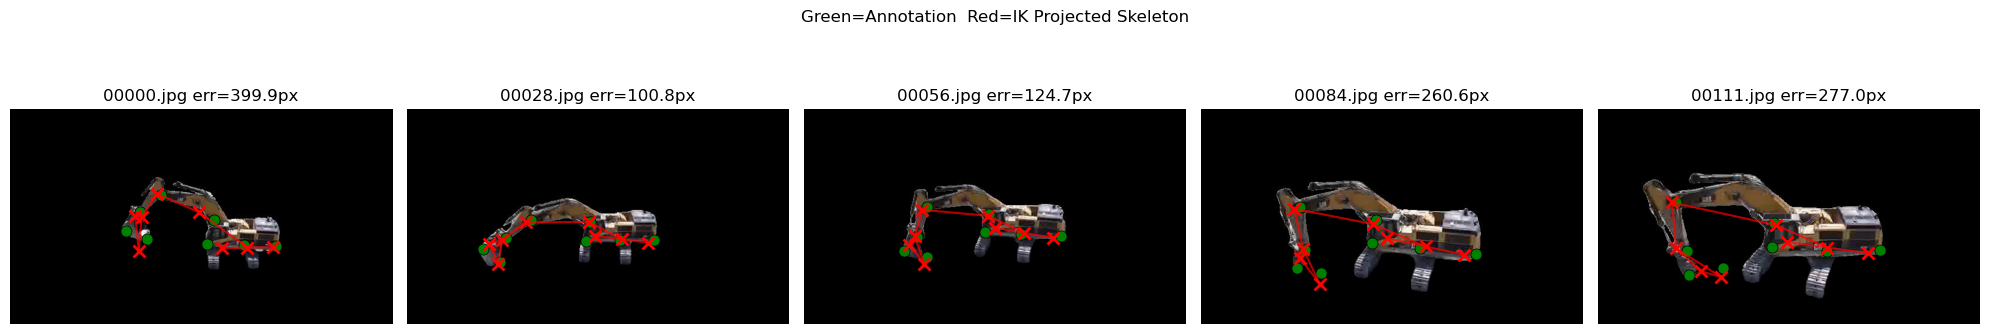

In [22]:
# Get sorted list of frame files
frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.jpg')])

# --- Overlay projected skeleton on frames ---
sample_indices = [0, len(frame_files) // 4, len(frame_files) // 2, 3 * len(frame_files) // 4, min(len(frame_files) - 1, n_frames - 1)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(20, 4))

for ax, idx in zip(axes, sample_indices):
    # Use actual filename
    img_path = os.path.join(frames_dir, frame_files[idx])
    if os.path.exists(img_path):
        ax.imshow(plt.imread(img_path))
    
    fi = idx  # Frame index in annotation data
    
    # Draw annotation keypoints (green)
    for i in range(n_kp):
        if visibility[fi, i] > 0.5:
            ax.plot(keypoints_2d[fi,i,0], keypoints_2d[fi,i,1], 'go',
                    markersize=8, markeredgecolor='black', markeredgewidth=0.5)

    # Draw projected skeleton (red)
    for i in range(n_kp):
        ax.plot(projected_2d[fi,i,0], projected_2d[fi,i,1], 'rx', markersize=8, markeredgewidth=2)
    
    # Draw projected skeleton edges
    for p1_name, p2_name in skeleton_edges:
        i1 = KEYPOINT_ORDER.index(p1_name)
        i2 = KEYPOINT_ORDER.index(p2_name)
        ax.plot([projected_2d[fi,i1,0], projected_2d[fi,i2,0]],
                [projected_2d[fi,i1,1], projected_2d[fi,i2,1]],
                'r-', linewidth=1.5, alpha=0.7)

    ax.set_title(f'{frame_files[idx]} err={errors[fi]:.1f}px')
    ax.axis('off')

plt.suptitle('Green=Annotation  Red=IK Projected Skeleton')
plt.tight_layout()
plt.show()

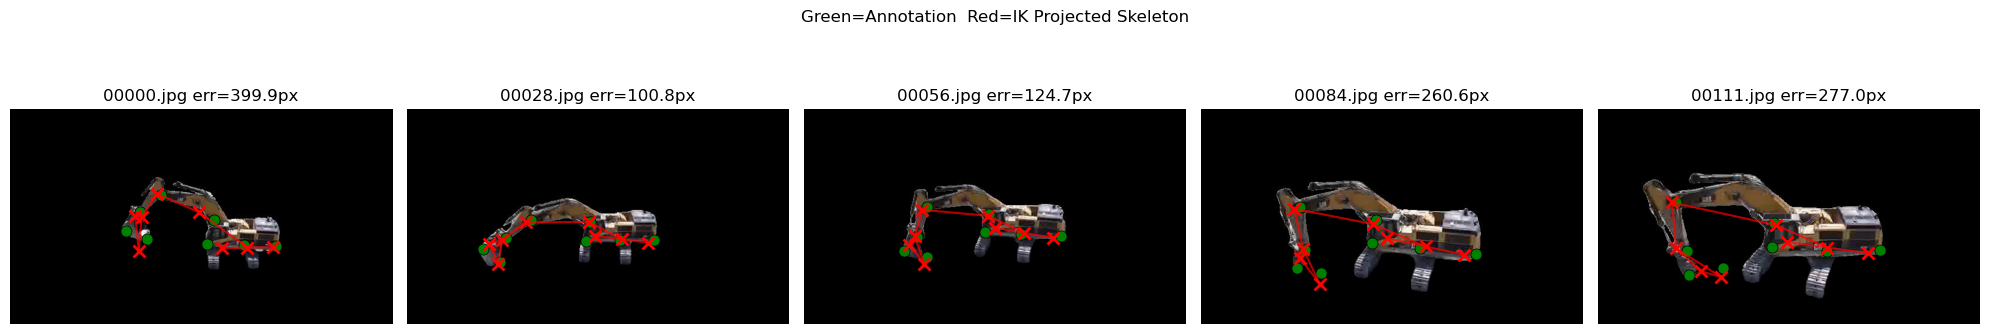

In [23]:
# Get sorted list of frame files
frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.jpg')])

# --- Overlay projected skeleton on frames ---
sample_indices = [0, len(frame_files) // 4, len(frame_files) // 2, 3 * len(frame_files) // 4, min(len(frame_files) - 1, n_frames - 1)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(20, 4))

for ax, idx in zip(axes, sample_indices):
    # Use actual filename from sorted list
    img_path = os.path.join(frames_dir, frame_files[idx])
    if os.path.exists(img_path):
        ax.imshow(plt.imread(img_path))
    
    fi = idx  # Frame index in annotation data
    
    # Draw annotation keypoints (green)
    for i in range(n_kp):
        if visibility[fi, i] > 0.5:
            ax.plot(keypoints_2d[fi,i,0], keypoints_2d[fi,i,1], 'go',
                    markersize=8, markeredgecolor='black', markeredgewidth=0.5)

    # Draw projected skeleton (red)
    for i in range(n_kp):
        ax.plot(projected_2d[fi,i,0], projected_2d[fi,i,1], 'rx', markersize=8, markeredgewidth=2)
    
    # Draw projected skeleton edges
    for p1_name, p2_name in skeleton_edges:
        i1 = KEYPOINT_ORDER.index(p1_name)
        i2 = KEYPOINT_ORDER.index(p2_name)
        ax.plot([projected_2d[fi,i1,0], projected_2d[fi,i2,0]],
                [projected_2d[fi,i1,1], projected_2d[fi,i2,1]],
                'r-', linewidth=1.5, alpha=0.7)

    ax.set_title(f'{frame_files[idx]} err={errors[fi]:.1f}px')
    ax.axis('off')

plt.suptitle('Green=Annotation  Red=IK Projected Skeleton')
plt.tight_layout()
plt.show()

In [ ]:
# Export to npz
output_path = '/home/caee/Desktop/RL_project/3_return/4/joint_angles.npz'

np.savez(
    output_path,
    joint_angles=joint_angles_smooth,          # (T, 4) smoothed angles in radians
    joint_angles_raw=joint_angles_raw,          # (T, 4) raw IK output
    joint_names=np.array(arm_joints),            # ['full_arm_rotation', 'lower_arm', 'upperToLow', 'scoop1']
    keypoint_names=np.array(KEYPOINT_ORDER),     # 8 keypoint names
    keypoints_2d=keypoints_2d,                   # (T, 8, 2) original annotations
    projected_2d=projected_2d,                   # (T, 8, 2) IK projected points
    reprojection_errors=errors,                  # (T,) per-frame error
    visibility=visibility,                       # (T, 8) occlusion flags
    annotation_source=annotation_path,
    urdf_path=urdf_path,
)

print(f'Saved to: {output_path}')
print(f'  joint_angles: {joint_angles_smooth.shape} (smoothed, radians)')
print(f'  joint_angles_raw: {joint_angles_raw.shape} (raw, radians)')
print(f'  joint_names: {arm_joints}')
print()
print('Joint angle summary (degrees):')
for i, name in enumerate(arm_joints):
    angles_deg = np.rad2deg(joint_angles_smooth[:, i])
    print(f'  {name:25s}: min={angles_deg.min():.1f}  max={angles_deg.max():.1f}  '
          f'range={angles_deg.ptp():.1f}  mean={angles_deg.mean():.1f}')
print()
print('To load:')
print(f"  data = np.load('{output_path}')")
print("  angles = data['joint_angles']      # (T, 4) radians")
print("  names = data['joint_names']         # joint names")

Saved to: /home/caee/Desktop/RL_project/Notestesetsets.npz
  joint_angles: (112, 4) (smoothed, radians)
  joint_angles_raw: (112, 4) (raw, radians)
  joint_names: ['full_arm_rotation', 'lower_arm', 'upperToLow', 'scoop1']

Joint angle summary (degrees):
  full_arm_rotation        : min=45.2  max=45.8  range=0.6  mean=45.8
  lower_arm                : min=8.5  max=57.3  range=48.8  mean=49.5
  upperToLow               : min=-26.9  max=17.2  range=44.1  mean=-1.7
  scoop1                   : min=-29.9  max=50.0  range=79.9  mean=-10.5

To load:
  data = np.load('/home/caee/Desktop/RL_project/Notestesetsets.npz')
  angles = data['joint_angles']      # (T, 4) radians
  names = data['joint_names']         # joint names


## 9. 3D Skeleton Playback

Animate the URDF skeleton in 3D using the solved joint angles.
Use the **slider** to scrub through frames and verify the IK solution looks correct.

In [24]:
import plotly.graph_objects as go

# Compute 3D keypoints for every frame using the solved joint angles
all_kp_3d = np.zeros((n_frames, n_kp, 3))
for t in range(n_frames):
    all_kp_3d[t] = skeleton.forward_kinematics(joint_angles_smooth[t])

# Build plotly figure with slider
fig = go.Figure()

# Add traces for frame 0 (initial)
kp = all_kp_3d[0]

# Keypoint markers
fig.add_trace(go.Scatter3d(
    x=kp[:, 0], y=kp[:, 1], z=kp[:, 2],
    mode='markers+text',
    marker=dict(size=8, color='red', line=dict(width=1, color='black')),
    text=KEYPOINT_ORDER,
    textposition='top center',
    textfont=dict(size=8),
    name='Keypoints',
    hovertemplate='<b>%{text}</b><br>X:%{x:.3f}<br>Y:%{y:.3f}<br>Z:%{z:.3f}<extra></extra>',
))

# Skeleton edges
edge_x, edge_y, edge_z = [], [], []
for p1_name, p2_name in skeleton_edges:
    i1 = KEYPOINT_ORDER.index(p1_name)
    i2 = KEYPOINT_ORDER.index(p2_name)
    edge_x.extend([kp[i1, 0], kp[i2, 0], None])
    edge_y.extend([kp[i1, 1], kp[i2, 1], None])
    edge_z.extend([kp[i1, 2], kp[i2, 2], None])

fig.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(color='blue', width=6),
    name='Skeleton',
    hoverinfo='skip',
))

# Build animation frames
frames = []
for t in range(n_frames):
    kp = all_kp_3d[t]
    ex, ey, ez = [], [], []
    for p1_name, p2_name in skeleton_edges:
        i1 = KEYPOINT_ORDER.index(p1_name)
        i2 = KEYPOINT_ORDER.index(p2_name)
        ex.extend([kp[i1, 0], kp[i2, 0], None])
        ey.extend([kp[i1, 1], kp[i2, 1], None])
        ez.extend([kp[i1, 2], kp[i2, 2], None])

    angles_deg = np.rad2deg(joint_angles_smooth[t])
    frame_label = (f'Frame {t} | '
                   f'arm_rot={angles_deg[0]:.1f} '
                   f'boom={angles_deg[1]:.1f} '
                   f'stick={angles_deg[2]:.1f} '
                   f'bucket={angles_deg[3]:.1f}')

    frames.append(go.Frame(
        data=[
            go.Scatter3d(x=kp[:, 0], y=kp[:, 1], z=kp[:, 2]),
            go.Scatter3d(x=ex, y=ey, z=ez),
        ],
        name=str(t),
        layout=go.Layout(title_text=frame_label),
    ))

fig.frames = frames

# Compute axis ranges from all frames
all_flat = all_kp_3d.reshape(-1, 3)
margin = 0.5
x_range = [all_flat[:, 0].min() - margin, all_flat[:, 0].max() + margin]
y_range = [all_flat[:, 1].min() - margin, all_flat[:, 1].max() + margin]
z_range = [all_flat[:, 2].min() - margin, all_flat[:, 2].max() + margin]

# Slider
sliders = [dict(
    active=0,
    currentvalue=dict(prefix='Frame: ', font=dict(size=14)),
    pad=dict(t=50),
    steps=[dict(args=[[str(t)], dict(mode='immediate', frame=dict(duration=0, redraw=True))],
                method='animate', label=str(t))
           for t in range(n_frames)]
)]

# Play/pause buttons
updatemenus = [dict(
    type='buttons',
    showactive=False,
    y=0, x=0.05, xanchor='right', yanchor='top',
    buttons=[
        dict(label='Play', method='animate',
             args=[None, dict(frame=dict(duration=80, redraw=True), fromcurrent=True)]),
        dict(label='Pause', method='animate',
             args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
    ]
)]

fig.update_layout(
    title='3D Skeleton Playback - Verify IK Solution',
    scene=dict(
        xaxis=dict(title='X', range=x_range),
        yaxis=dict(title='Y', range=y_range),
        zaxis=dict(title='Z', range=z_range),
        aspectmode='data',
        camera=dict(eye=dict(x=2.0, y=0.5, z=1.0)),
    ),
    sliders=sliders,
    updatemenus=updatemenus,
    width=1200, height=800,
)

print(f'3D playback ready ({n_frames} frames)')
print('  Use slider to scrub through frames')
print('  Play/Pause buttons for animation')
print('  Rotate/zoom the 3D view with mouse')
fig.show()

3D playback ready (112 frames)
  Use slider to scrub through frames
  Play/Pause buttons for animation
  Rotate/zoom the 3D view with mouse


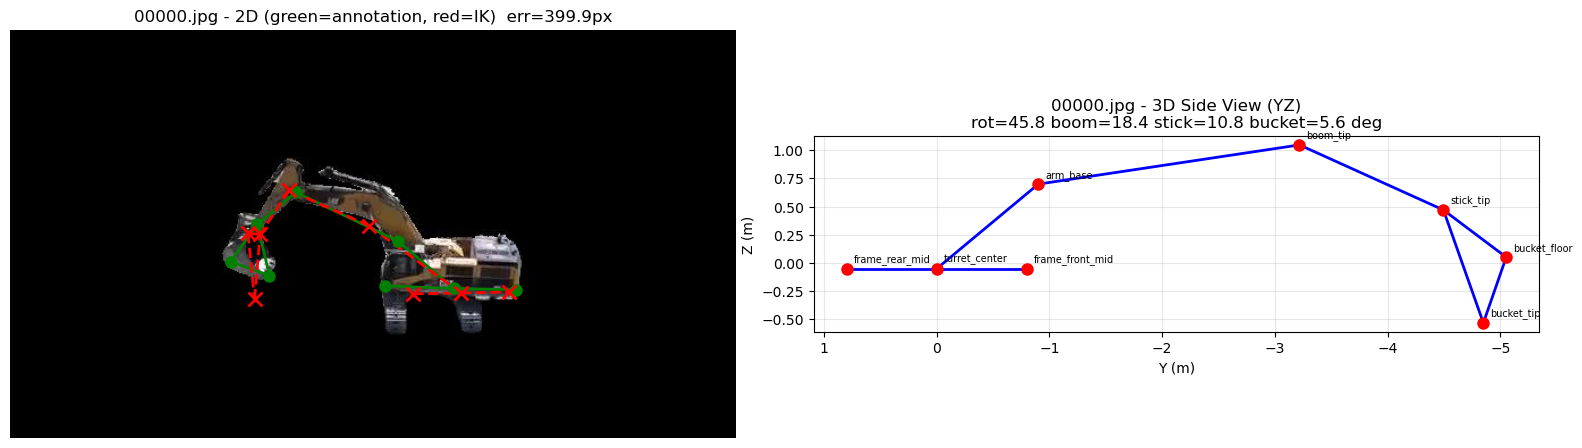

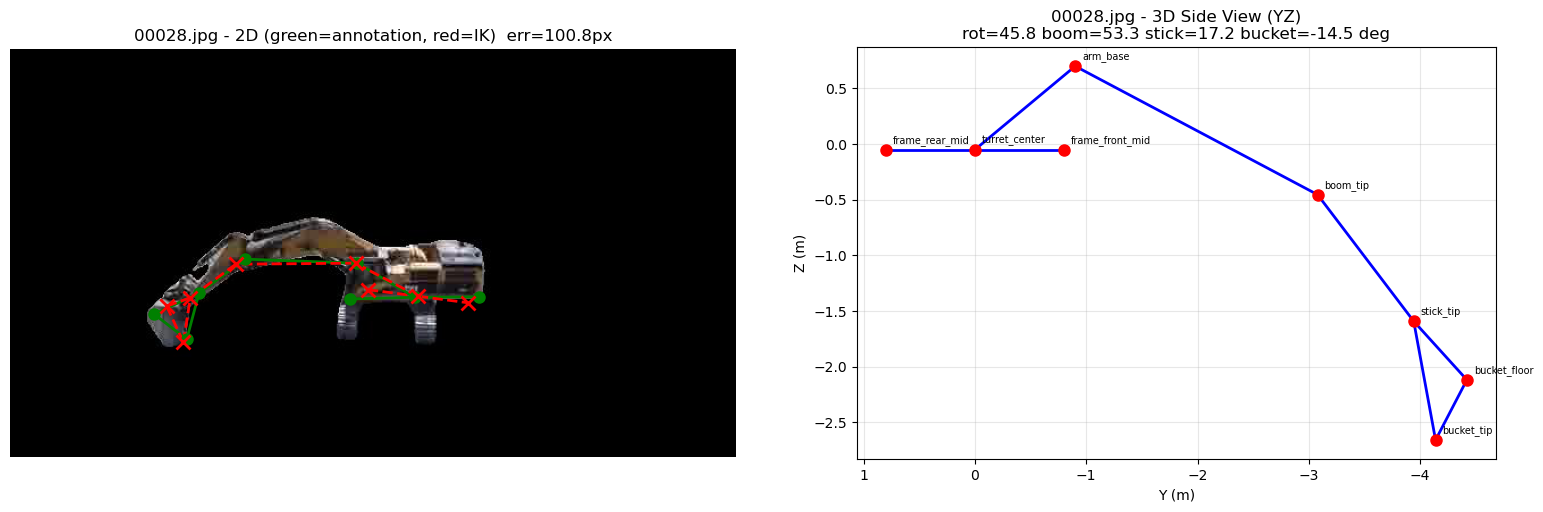

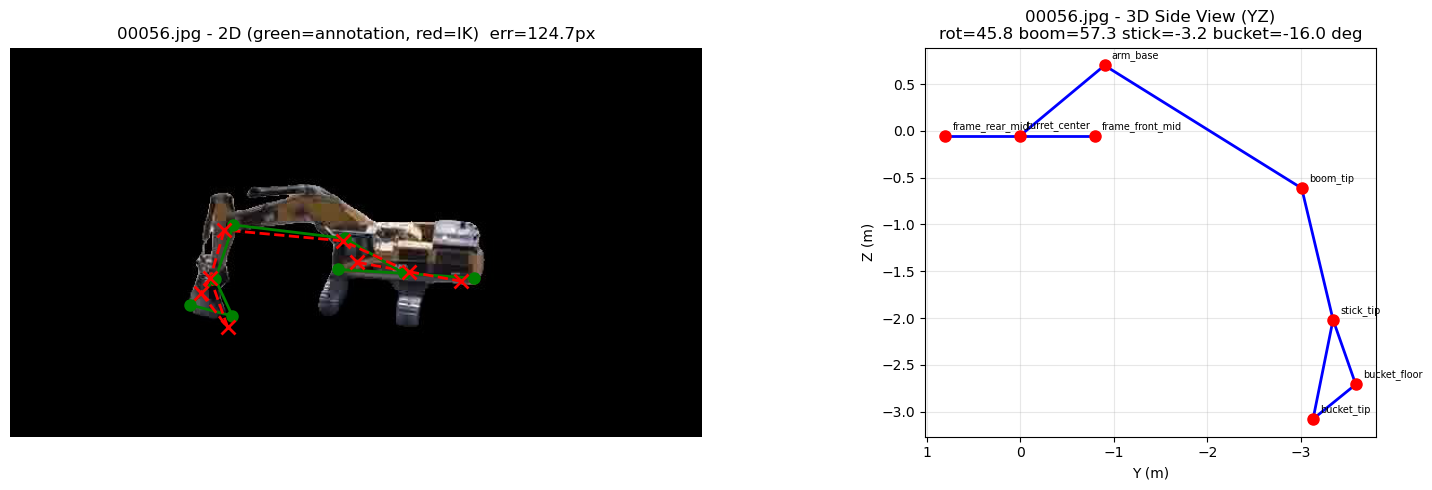

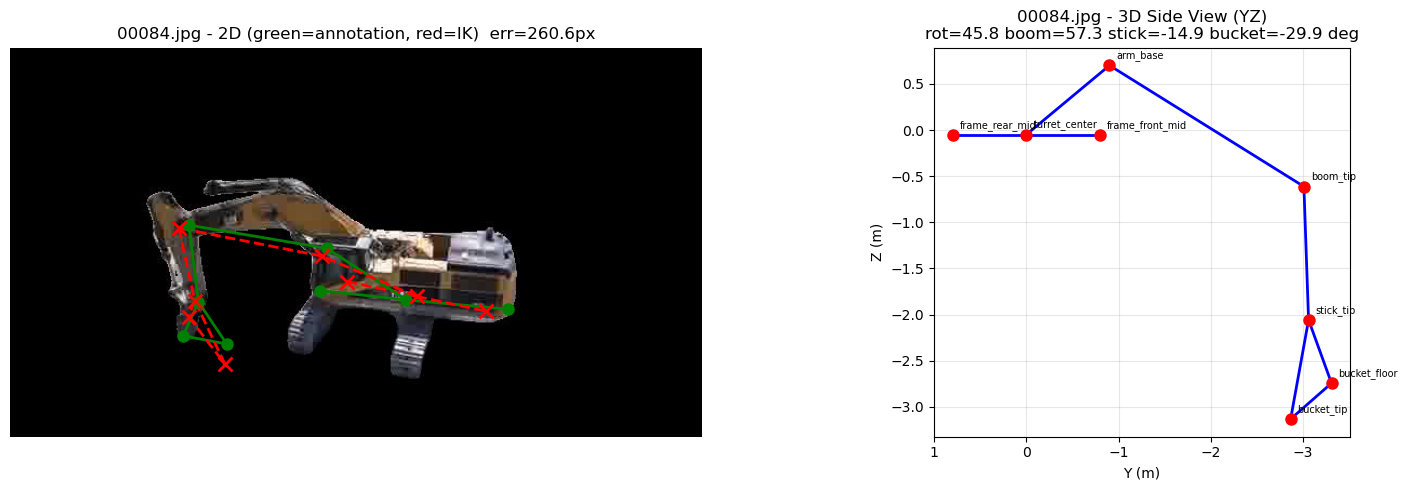

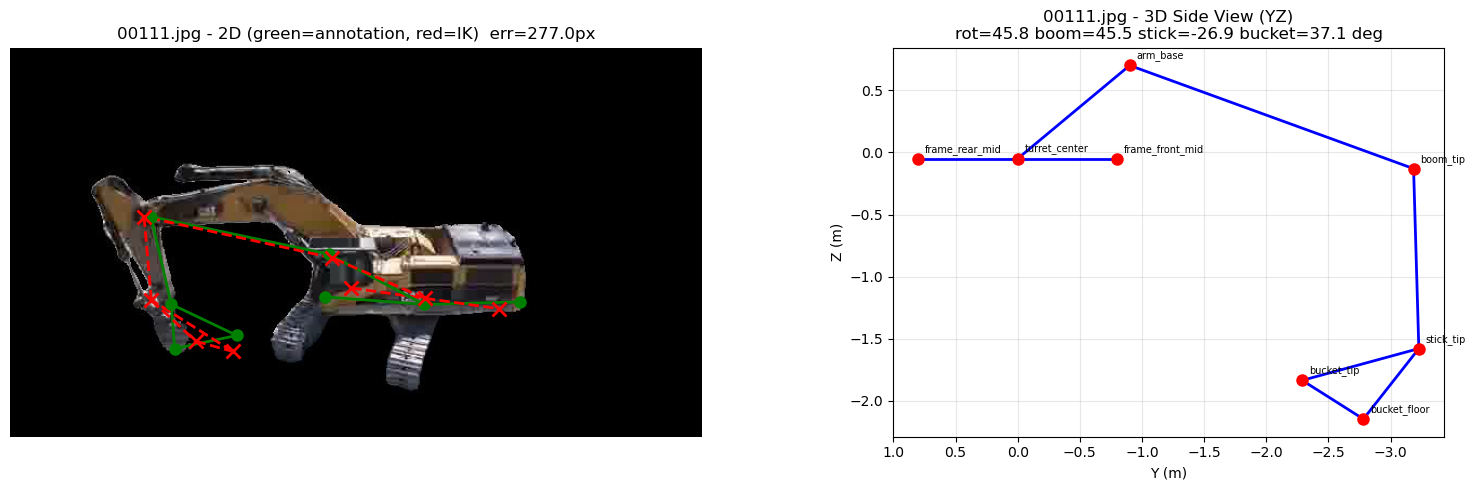

In [25]:
# Get sorted list of frame files
frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.jpg')])

# Side-by-side comparison for specific frames
check_indices = [0, len(frame_files)//4, len(frame_files)//2, 3*len(frame_files)//4, min(len(frame_files)-1, n_frames-1)]

for idx in check_indices:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    fi = idx  # Frame index in annotation data

    # Left: 2D annotation on image
    img_path = os.path.join(frames_dir, frame_files[idx])
    if os.path.exists(img_path):
        ax1.imshow(plt.imread(img_path))
    for p1_name, p2_name in skeleton_edges:
        i1 = KEYPOINT_ORDER.index(p1_name)
        i2 = KEYPOINT_ORDER.index(p2_name)
        ax1.plot([keypoints_2d[fi,i1,0], keypoints_2d[fi,i2,0]],
                 [keypoints_2d[fi,i1,1], keypoints_2d[fi,i2,1]], 'g-', linewidth=2)
        ax1.plot([projected_2d[fi,i1,0], projected_2d[fi,i2,0]],
                 [projected_2d[fi,i1,1], projected_2d[fi,i2,1]], 'r--', linewidth=2)
    for i, name in enumerate(KEYPOINT_ORDER):
        ax1.plot(keypoints_2d[fi,i,0], keypoints_2d[fi,i,1], 'go', markersize=8)
        ax1.plot(projected_2d[fi,i,0], projected_2d[fi,i,1], 'rx', markersize=10, markeredgewidth=2)
    ax1.set_title(f'{frame_files[idx]} - 2D (green=annotation, red=IK)  err={errors[fi]:.1f}px')
    ax1.axis('off')

    # Right: 3D skeleton (YZ side view)
    kp = all_kp_3d[fi]
    for p1_name, p2_name in skeleton_edges:
        i1 = KEYPOINT_ORDER.index(p1_name)
        i2 = KEYPOINT_ORDER.index(p2_name)
        ax2.plot([kp[i1, 1], kp[i2, 1]], [kp[i1, 2], kp[i2, 2]], 'b-', linewidth=2)
    for i, name in enumerate(KEYPOINT_ORDER):
        ax2.plot(kp[i, 1], kp[i, 2], 'ro', markersize=8)
        ax2.annotate(name, (kp[i, 1], kp[i, 2]), fontsize=7,
                     xytext=(5, 5), textcoords='offset points')

    angles_deg = np.rad2deg(joint_angles_smooth[fi])
    ax2.set_title(f'{frame_files[idx]} - 3D Side View (YZ)\n'
                  f'rot={angles_deg[0]:.1f} boom={angles_deg[1]:.1f} '
                  f'stick={angles_deg[2]:.1f} bucket={angles_deg[3]:.1f} deg')
    ax2.set_xlabel('Y (m)')
    ax2.set_ylabel('Z (m)')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.invert_xaxis()  # Match image orientation

    plt.tight_layout()
    plt.show()

## 11. Build BC Training Dataset

Convert joint angle trajectories into state-action pairs for behavioral cloning.

- **State**: joint positions at time t -> (4,)
- **Action**: joint positions at time t+1 -> (4,) (position target)
- **Frequency**: 10 Hz

This cell can load **multiple** npz files from different videos and concatenate them.

In [13]:
import glob

# --- List all npz files to include ---
# Add paths to all your processed annotation npz files here
npz_files = [
    '/home/caee/Desktop/RL_project/3_return/4/joint_angles.npz',
    # Add more as you process them:
    # '/home/caee/Desktop/RL_project/0_dig/2/joint_angles.npz',
    # '/home/caee/Desktop/RL_project/1_dump/1/joint_angles.npz',
    # '/home/caee/Desktop/RL_project/2_swing/1/joint_angles.npz',
]

# Or auto-discover all npz files:
# npz_files = sorted(glob.glob('/home/caee/Desktop/RL_project/**/joint_angles.npz', recursive=True))

print(f'Loading {len(npz_files)} trajectory file(s)...\n')

all_states = []
all_actions = []
trajectory_info = []

for path in npz_files:
    data = np.load(path, allow_pickle=True)
    angles = data['joint_angles']  # (T, 4)
    names = data['joint_names']
    T = len(angles)

    # State-action pairs: state[t] -> action[t] = state[t+1]
    states = angles[:-1]   # (T-1, 4)
    actions = angles[1:]   # (T-1, 4)

    all_states.append(states)
    all_actions.append(actions)
    trajectory_info.append({'path': path, 'frames': T, 'pairs': T - 1})

    print(f'  {os.path.basename(os.path.dirname(path))}: {T} frames -> {T-1} pairs')

# Concatenate all trajectories
all_states = np.concatenate(all_states, axis=0)    # (N, 4)
all_actions = np.concatenate(all_actions, axis=0)   # (N, 4)

print(f'\nTotal: {len(all_states)} state-action pairs')
print(f'  State dim:  {all_states.shape[1]} (joint positions in radians)')
print(f'  Action dim: {all_actions.shape[1]} (target joint positions in radians)')
print(f'  Frequency:  10 Hz')

Loading 1 trajectory file(s)...

  4: 18 frames -> 17 pairs

Total: 17 state-action pairs
  State dim:  4 (joint positions in radians)
  Action dim: 4 (target joint positions in radians)
  Frequency:  10 Hz


In [14]:
# --- Normalize ---
state_mean = all_states.mean(axis=0)
state_std = all_states.std(axis=0)
state_std[state_std < 1e-6] = 1.0  # avoid division by zero for constant joints

action_mean = all_actions.mean(axis=0)
action_std = all_actions.std(axis=0)
action_std[action_std < 1e-6] = 1.0

states_norm = (all_states - state_mean) / state_std
actions_norm = (all_actions - action_mean) / action_std

print('Normalization stats:')
print(f'  State  mean: {state_mean}')
print(f'  State  std:  {state_std}')
print(f'  Action mean: {action_mean}')
print(f'  Action std:  {action_std}')
print()
print(f'Normalized state  range: [{states_norm.min():.2f}, {states_norm.max():.2f}]')
print(f'Normalized action range: [{actions_norm.min():.2f}, {actions_norm.max():.2f}]')

Normalization stats:
  State  mean: [ 0.8         0.01403021 -0.61764706 -0.63254167]
  State  std:  [1.         0.21548087 0.4374193  0.04291134]
  Action mean: [ 0.8         0.04506708 -0.54705882 -0.64057434]
  Action std:  [1.         0.24556649 0.48082973 0.04785077]

Normalized state  range: [-2.10, 2.22]
Normalized action range: [-1.93, 1.92]


In [15]:
# --- Save BC dataset ---
bc_output_path = '/home/caee/Desktop/RL_project/3_return/4/bc_dataset.npz'

np.savez(
    bc_output_path,
    # Raw data
    states=all_states,              # (N, 4) joint positions in radians
    actions=all_actions,            # (N, 4) target joint positions in radians
    # Normalized data
    states_norm=states_norm,        # (N, 4) zero-mean unit-variance
    actions_norm=actions_norm,      # (N, 4) zero-mean unit-variance
    # Normalization params (needed at inference time)
    state_mean=state_mean,          # (4,)
    state_std=state_std,            # (4,)
    action_mean=action_mean,        # (4,)
    action_std=action_std,          # (4,)
    # Metadata
    joint_names=names,              # ['full_arm_rotation', 'lower_arm', 'upperToLow', 'scoop1']
    frequency=np.array(10),         # Hz
    n_trajectories=np.array(len(npz_files)),
)

print(f'BC dataset saved to: {bc_output_path}')
print(f'  {len(all_states)} state-action pairs from {len(npz_files)} trajectory(s)')
print()
print('To load for training:')
print(f"  data = np.load('{bc_output_path}')")
print("  states = data['states_norm']    # (N, 4) normalized")
print("  actions = data['actions_norm']   # (N, 4) normalized")
print()
print('To denormalize predictions at inference:')
print("  action_raw = prediction * data['action_std'] + data['action_mean']")

BC dataset saved to: /home/caee/Desktop/RL_project/3_return/4/bc_dataset.npz
  17 state-action pairs from 1 trajectory(s)

To load for training:
  data = np.load('/home/caee/Desktop/RL_project/3_return/4/bc_dataset.npz')
  states = data['states_norm']    # (N, 4) normalized
  actions = data['actions_norm']   # (N, 4) normalized

To denormalize predictions at inference:
  action_raw = prediction * data['action_std'] + data['action_mean']
